
Normal (Label 0): s10_0000_label0.npy
Shape: (27000,), dtype: float32
Segment duration: 135 seconds
Sampling rate: 200.00 Hz
Min: -6.920, Max: 4.649, Mean: 0.000121

Apnea/Hypopnea (Label 1): s10_0020_label1.npy
Shape: (27000,), dtype: float32
Segment duration: 135 seconds
Sampling rate: 200.00 Hz
Min: -5.939, Max: 2.807, Mean: -0.000025


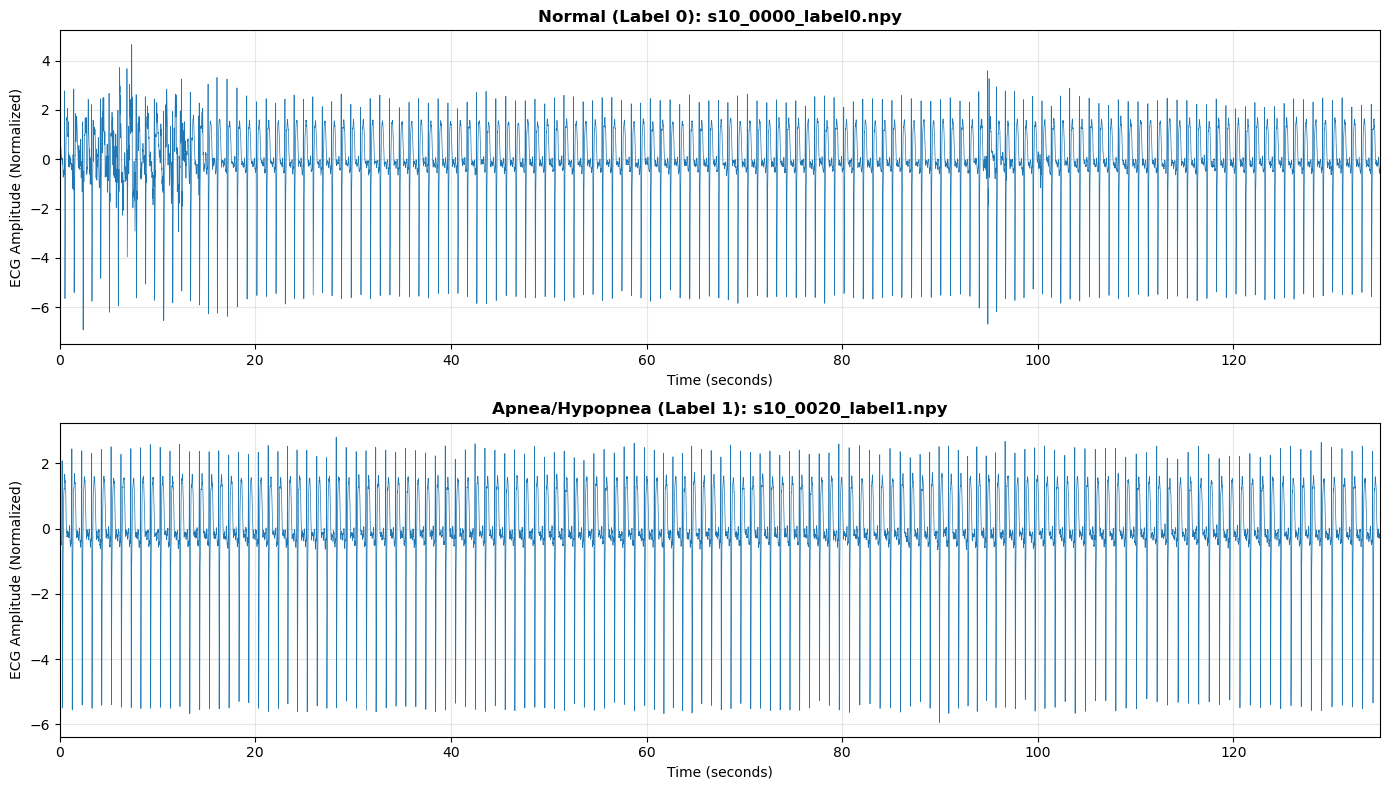


Total files: 80493
Label 0 (Normal): 45062 files
Label 1 (Apnea/Hypopnea): 35431 files


In [6]:
# Preview samples from both classes: normal (label0) and apnea (label1)
import os
import numpy as np
import matplotlib.pyplot as plt

data_dir = 'segmented_npy'
files = sorted([f for f in os.listdir(data_dir) if f.endswith('.npy')])

if not files:
    print(f"No .npy files found in {data_dir}")
else:
    # Find one file for each label
    label0_file = next((f for f in files if 'label0' in f), None)
    label1_file = next((f for f in files if 'label1' in f), None)
    
    segment_duration = 135  # seconds
    
    # Plot both samples
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    for idx, (file, label_name, ax) in enumerate([
        (label0_file, "Normal (Label 0)", axes[0]),
        (label1_file, "Apnea/Hypopnea (Label 1)", axes[1])
    ]):
        if file is None:
            ax.text(0.5, 0.5, f'No {label_name} file found', 
                   ha='center', va='center', transform=ax.transAxes)
            continue
        
        print(f"\n{'='*60}")
        print(f"{label_name}: {file}")
        print(f"{'='*60}")
        
        path = os.path.join(data_dir, file)
        arr = np.load(path, allow_pickle=True)
        
        sampling_rate = arr.shape[0] / segment_duration
        
        print(f"Shape: {arr.shape}, dtype: {arr.dtype}")
        print(f"Segment duration: {segment_duration} seconds")
        print(f"Sampling rate: {sampling_rate:.2f} Hz")
        print(f"Min: {np.min(arr):.3f}, Max: {np.max(arr):.3f}, Mean: {np.mean(arr):.6f}")
        
        # Create time axis in seconds
        time_seconds = np.arange(arr.shape[0]) / sampling_rate
        
        # Plot
        ax.plot(time_seconds, arr, linewidth=0.5)
        ax.set_title(f'{label_name}: {file}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Time (seconds)')
        ax.set_ylabel('ECG Amplitude (Normalized)')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, segment_duration)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{'='*60}")
    print(f"Total files: {len(files)}")
    print(f"Label 0 (Normal): {sum(1 for f in files if 'label0' in f)} files")
    print(f"Label 1 (Apnea/Hypopnea): {sum(1 for f in files if 'label1' in f)} files")

Normal segments: 45062, Apnea segments: 35431


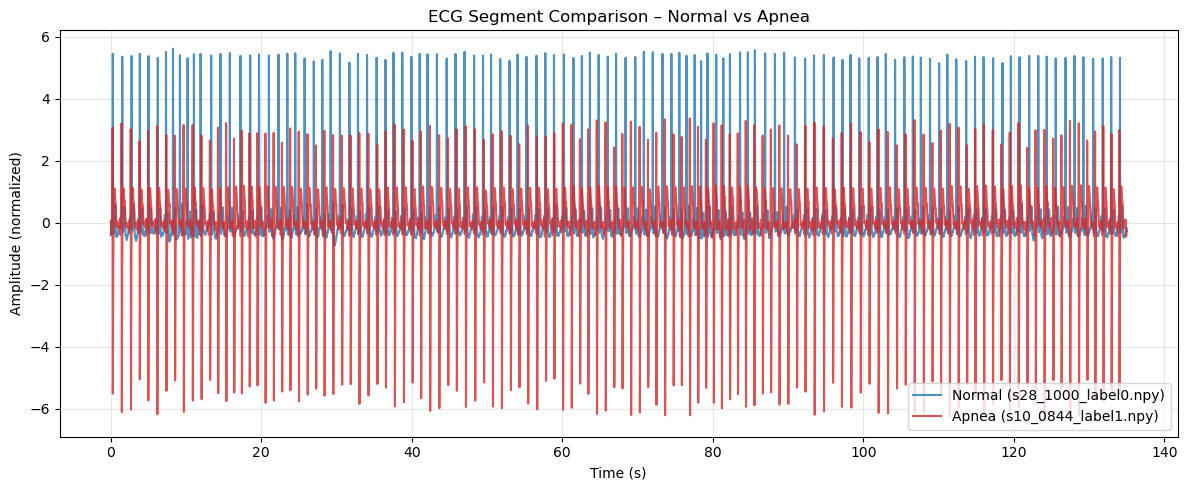

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import glob, random

# gather files
files = glob.glob("segmented_npy/*.npy")
normal_files = [f for f in files if "label0" in f]
apnea_files  = [f for f in files if "label1" in f]

print(f"Normal segments: {len(normal_files)}, Apnea segments: {len(apnea_files)}")

# pick one of each
import random
normal_file = random.choice(normal_files)
apnea_file  = random.choice(apnea_files)

# load (1-D arrays)
x_normal = np.load(normal_file)
x_apnea  = np.load(apnea_file)

fs = 200
t = np.arange(len(x_normal)) / fs

# plot
plt.figure(figsize=(12,5))
plt.plot(t, x_normal, color='tab:blue', alpha=0.8, label=f'Normal ({normal_file.split("/")[-1]})')
plt.plot(t, x_apnea,  color='tab:red',  alpha=0.8, label=f'Apnea ({apnea_file.split("/")[-1]})')
plt.title("ECG Segment Comparison – Normal vs Apnea")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (normalized)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
